# LightGBM with Optuna Hyperparameter Tuning

This notebook demonstrates LightGBM hyperparameter optimization using Optuna:

1. **Data Processing**: Load raw data, clean source attribution, remove duplicates
2. **Train/Test Split**: Stratified split with configurable columns
3. **Feature Engineering**: TF-IDF vectorization
4. **Hyperparameter Optimization**: Optuna-based tuning with cross-validation
5. **Model Training**: Train final model with best parameters
6. **Feature Importance**: Analyze what drives predictions

**Key improvement over base experiment**: Uses Optuna to automatically find optimal hyperparameters through Bayesian optimization with TPE sampler.


In [1]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import joblib
import warnings

# Optuna imports
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

# LightGBM
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import modules (with reload to pick up any changes)
from src.data import process_dataset, make_split
from src.features import make_features
from src.models import train_model as train_model_module

importlib.reload(make_features)
importlib.reload(train_model_module)

run_feature_engineering = make_features.run_feature_engineering
load_config = train_model_module.load_config

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✓ Imports successful")
print(f"  Optuna version: {optuna.__version__}")


✓ Imports successful
  Optuna version: 3.2.0


In [2]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'


## 1. Data Processing

Load raw data, clean source attribution (e.g., "(Reuters) -"), and remove duplicates.


In [3]:
# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
cleaned_data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

# Process dataset: load, clean source attribution, deduplicate
df = process_dataset(
    input_path=str(raw_data_path),
    output_path=str(cleaned_data_path),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    id_column=ID_COLUMN
)


DATA PROCESSING
Input:  /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

1. Loading dataset...
   Loaded 72,134 rows
   Columns: ['id', 'title', 'text', 'label']

2. Cleaning source attribution from 'text' column...
   Removing patterns like '(Reuters) -', '(AP) -', etc.
   ✓ Source attribution removed

3. Removing duplicate articles (based on 'text')...
   Removed 27,695 duplicates
   Remaining: 44,439 unique articles

4. Label distribution ('label' column):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

5. Saving cleaned data...
✓ Saved 44439 rows to /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

✓ DATA PROCESSING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Total rows:     44,439
  Saved to:       /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv


## 2. Train/Test Split

Create stratified train/test split (80/20) based on label column.


In [4]:
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(cleaned_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"],
    label_column=LABEL_COLUMN,
    feature_column=FEATURE_COLUMN
)


TRAIN/TEST SPLIT

1. Loading data from /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv...
   Loaded 44,439 rows

2. Validating columns...
   Feature column (X): 'text'
   Label column (y):   'label'
   ✓ All required columns present

3. Label distribution (before split):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

4. Splitting data (test_size=0.2, random_seed=42)...

5. Saving splits...
   Train: /Users/alanye/Fake-News-Group-3/data/processed/train.csv (35,551 rows)
   Test:  /Users/alanye/Fake-News-Group-3/data/processed/test.csv (8,888 rows)

✓ SPLIT COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Train samples:  35,551
  Test samples:   8,888


## 3. Feature Engineering

Convert text to TF-IDF vectors (unigrams + bigrams, max 5000 features).


In [5]:
run_feature_engineering(
    processed_dir=str(processed_dir),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    max_features=config["features"]["tfidf"]["max_features"]
)


FEATURE ENGINEERING

1. Loading train/test split...

2. Extracting features and labels...
   Feature column (X): 'text'
   Label column (y):   'label'

   Train samples: 35,551
   Test samples:  8,888

   Label distribution (train):
     0 (Real): 23,649 (66.5%)
     1 (Fake): 11,902 (33.5%)

3. Creating TF-IDF features...
   Max features: 5,000
   N-gram range: (1, 2)
   ✓ Train TF-IDF shape: (35551, 5000)
   ✓ Test TF-IDF shape:  (8888, 5000)

4. Creating Word2Vec/Sentence2Vec features...
   Training Word2Vec model...
   Generating sentence vectors...
   ✓ Train W2V shape: (35551, 100)
   ✓ Test W2V shape:  (8888, 100)

5. Saving features to /Users/alanye/Fake-News-Group-3/data/processed...
   ✓ TF-IDF features saved
   ✓ Word2Vec features saved

✓ FEATURE ENGINEERING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  TF-IDF shape:   (35551, 5000)
  Word2Vec shape: (35551, 100)


In [6]:
# Load features for Optuna optimization
train_data = np.load(str(processed_dir / "features_train_tfidf.npz"), allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

test_data = np.load(str(processed_dir / "features_test_tfidf.npz"), allow_pickle=True)
X_test = test_data["X"].item()
y_test = test_data["y"]

print(f"Training data: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test data: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nLabel distribution (train): 0={np.sum(y_train==0)}, 1={np.sum(y_train==1)}")
print(f"Label distribution (test): 0={np.sum(y_test==0)}, 1={np.sum(y_test==1)}")


Training data: 35551 samples, 5000 features
Test data: 8888 samples, 5000 features

Label distribution (train): 0=23649, 1=11902
Label distribution (test): 0=5912, 1=2976


## 4. Hyperparameter Optimization with Optuna

Define the objective function and hyperparameter search space for LightGBM optimization.

**Search Space:**
- `n_estimators`: [50, 500]
- `learning_rate`: [0.01, 0.3] (log scale)
- `num_leaves`: [15, 127]
- `max_depth`: [3, 12]
- `min_child_samples`: [5, 100]
- `subsample`: [0.5, 1.0]
- `colsample_bytree`: [0.5, 1.0]
- `reg_alpha`: [1e-8, 10.0] (log scale)
- `reg_lambda`: [1e-8, 10.0] (log scale)


In [7]:
def objective(trial):
    """Optuna objective function for LightGBM hyperparameter optimization."""
    
    # Define hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'binary',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Create LightGBM classifier
    model = lgb.LGBMClassifier(**params)
    
    # Use 5-fold stratified cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Evaluate using F1-score (macro average)
    scores = cross_val_score(
        model, X_train, y_train, 
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    
    return scores.mean()

print("✓ Objective function defined")
print("  - Uses 5-fold stratified cross-validation")
print("  - Optimizes F1-score (macro average)")


✓ Objective function defined
  - Uses 5-fold stratified cross-validation
  - Optimizes F1-score (macro average)


In [8]:
# Configuration for optimization
N_TRIALS = 100  # Number of optimization trials
RANDOM_SEED = 42

print("=" * 60)
print("OPTUNA HYPERPARAMETER OPTIMIZATION")
print("=" * 60)
print(f"\nConfiguration:")
print(f"  Number of trials: {N_TRIALS}")
print(f"  Sampler: TPE (Tree-structured Parzen Estimator)")
print(f"  Metric: F1-score (macro)")
print(f"  Cross-validation: 5-fold stratified")
print(f"\nStarting optimization...")

# Create Optuna study with TPE sampler
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name='lgbm_fake_news_detection'
)

# Run optimization
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✓ Optimization complete!")


OPTUNA HYPERPARAMETER OPTIMIZATION

Configuration:
  Number of trials: 100
  Sampler: TPE (Tree-structured Parzen Estimator)
  Metric: F1-score (macro)
  Cross-validation: 5-fold stratified

Starting optimization...


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Optimization complete!


In [9]:
# Display best parameters and results
print("=" * 60)
print("OPTIMIZATION RESULTS")
print("=" * 60)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best F1-score (CV): {study.best_value:.4f}")

print(f"\nBest hyperparameters:")
for param, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.6f}")
    else:
        print(f"  {param}: {value}")

# Show top 5 trials
print(f"\nTop 5 trials:")
trials_df = study.trials_dataframe()
trials_df_sorted = trials_df.sort_values('value', ascending=False).head(5)
print(trials_df_sorted[['number', 'value', 'state']].to_string(index=False))


OPTIMIZATION RESULTS

Best trial: #11
Best F1-score (CV): 0.9331

Best hyperparameters:
  n_estimators: 499
  learning_rate: 0.287572
  num_leaves: 46
  max_depth: 12
  min_child_samples: 59
  subsample: 0.631136
  colsample_bytree: 0.505511
  reg_alpha: 0.003473
  reg_lambda: 0.003938

Top 5 trials:
 number    value    state
     11 0.933141 COMPLETE
     71 0.932261 COMPLETE
     41 0.932213 COMPLETE
     94 0.932166 COMPLETE
     54 0.932045 COMPLETE


## 5. Train Final Model with Best Parameters

Train the final LightGBM model using the optimized hyperparameters and evaluate on the held-out test set.


In [10]:
print("=" * 60)
print("TRAINING FINAL MODEL")
print("=" * 60)

# Create final model with best parameters
best_params = study.best_params.copy()
best_params['objective'] = 'binary'
best_params['verbosity'] = -1
best_params['random_state'] = 42
best_params['n_jobs'] = -1

print(f"\nUsing optimized hyperparameters:")
for param, value in best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.6f}")
    else:
        print(f"  {param}: {value}")

# Train final model
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

print(f"\n✓ Final model trained on {X_train.shape[0]} samples")


TRAINING FINAL MODEL

Using optimized hyperparameters:
  n_estimators: 499
  learning_rate: 0.287572
  num_leaves: 46
  max_depth: 12
  min_child_samples: 59
  subsample: 0.631136
  colsample_bytree: 0.505511
  reg_alpha: 0.003473
  reg_lambda: 0.003938
  objective: binary
  verbosity: -1
  random_state: 42
  n_jobs: -1

✓ Final model trained on 35551 samples


In [11]:
# Evaluate on test set
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='macro')
report = classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)'], output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"\nAccuracy: {test_accuracy:.4f}")
print(f"F1-score (macro): {test_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)']))


TEST SET EVALUATION

Accuracy: 0.9412
F1-score (macro): 0.9336

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.95      0.96      0.96      5912
    Fake (1)       0.92      0.90      0.91      2976

    accuracy                           0.94      8888
   macro avg       0.94      0.93      0.93      8888
weighted avg       0.94      0.94      0.94      8888



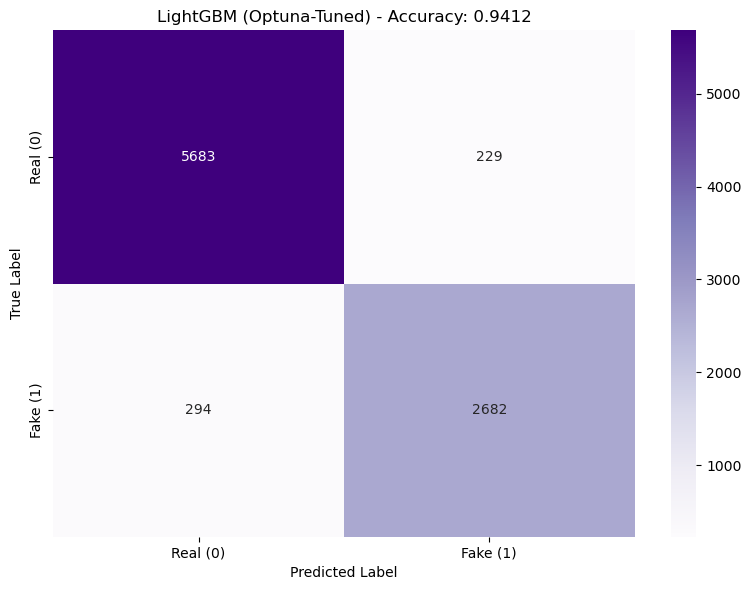

In [12]:
# Confusion Matrix visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax.set_title(f"LightGBM (Optuna-Tuned) - Accuracy: {test_accuracy:.4f}")
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()


## 6. Optuna Optimization Visualizations

Visualize the hyperparameter optimization process to understand:
1. **Optimization History**: How the best score improved over trials
2. **Parameter Importance**: Which hyperparameters had the most impact
3. **Parallel Coordinates**: Relationships between parameters and performance


In [13]:
# Optimization History Plot
print("=" * 60)
print("1. OPTIMIZATION HISTORY")
print("=" * 60)

fig = plot_optimization_history(study)
fig.update_layout(title="Optimization History: F1-Score (Macro) vs Trial")
fig.show()


1. OPTIMIZATION HISTORY


In [14]:
# Parameter Importance Plot
print("=" * 60)
print("2. PARAMETER IMPORTANCE")
print("=" * 60)

fig = plot_param_importances(study)
fig.update_layout(title="Hyperparameter Importance for F1-Score")
fig.show()


2. PARAMETER IMPORTANCE


In [15]:
# Parallel Coordinates Plot
print("=" * 60)
print("3. PARALLEL COORDINATES")
print("=" * 60)

fig = plot_parallel_coordinate(study)
fig.update_layout(title="Hyperparameter Relationships (Parallel Coordinates)")
fig.show()


3. PARALLEL COORDINATES


## 7. Feature Importance Analysis

Analyze which words/n-grams are most predictive of fake vs real news using multiple methods:

1. **MDI (Mean Decrease in Impurity)**: LGBM's built-in `feature_importances_` based on gain
2. **Permutation Feature Importance**: Measures importance by shuffling features and observing accuracy drop
3. **SHAP (SHapley Additive exPlanations)**: Game-theoretic approach for consistent feature attributions


In [16]:
from sklearn.inspection import permutation_importance

# Load the TF-IDF vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

print("=" * 60)
print("1. MDI (Mean Decrease in Impurity) Feature Importance")
print("   (Built-in LGBM feature_importances_ based on gain)")
print("=" * 60)

# MDI Feature Importance (built-in)
mdi_importances = final_model.feature_importances_
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False)

print(f"\nTop 20 features by MDI:")
print(mdi_df.head(20).to_string(index=False))


1. MDI (Mean Decrease in Impurity) Feature Importance
   (Built-in LGBM feature_importances_ based on gain)

Top 20 features by MDI:
     feature  importance
        said         614
         new         246
   president         244
      people         236
        just         195
        time         194
        like         191
        year         149
        told         140
       trump         138
        2016         130
       state         124
   according         111
     hillary         102
        news         102
    american          93
       years          89
      states          87
       obama          86
donald trump          86


In [17]:
print("\n" + "=" * 60)
print("2. Permutation Feature Importance")
print("   (Measures accuracy drop when shuffling features)")
print("=" * 60)

# Use a sample for permutation importance (sparse to dense conversion requires memory)
perm_sample_size = min(2000, X_test.shape[0])
print(f"\nUsing {perm_sample_size} samples for permutation importance...")

# Convert sparse to dense for the sample
if hasattr(X_test, 'toarray'):
    X_test_sample = X_test[:perm_sample_size].toarray()
else:
    X_test_sample = X_test[:perm_sample_size]
y_test_sample = y_test[:perm_sample_size]

print("Computing permutation importance (this may take a moment)...")
perm_result = permutation_importance(
    final_model, X_test_sample, y_test_sample, 
    n_repeats=10, random_state=42, n_jobs=-1, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"\nTop 20 features by Permutation Importance:")
print(perm_df.head(20).to_string(index=False))



2. Permutation Feature Importance
   (Measures accuracy drop when shuffling features)

Using 2000 samples for permutation importance...
Computing permutation importance (this may take a moment)...

Top 20 features by Permutation Importance:
         feature  importance_mean  importance_std
            said          0.00885        0.002303
              mr          0.00410        0.001375
         hillary          0.00355        0.002392
president donald          0.00330        0.001145
         october          0.00220        0.001005
          sunday          0.00215        0.001534
             new          0.00175        0.001585
            2016          0.00145        0.001059
             fbi          0.00135        0.000867
             rep          0.00135        0.000450
          friday          0.00120        0.001749
           party          0.00120        0.000872
  nominee donald          0.00110        0.000200
         reuters          0.00105        0.000986
        

In [18]:
print("\n" + "=" * 60)
print("3. SHAP (SHapley Additive exPlanations)")
print("   (Game-theoretic feature attributions)")
print("=" * 60)

try:
    import shap
    
    # Use a sample of test data for SHAP (to keep computation manageable)
    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test[:sample_size].toarray()  # Convert sparse to dense for SHAP
    
    print(f"\nComputing SHAP values on {sample_size} samples...")
    
    # Create SHAP explainer for tree-based model
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_sample)
    
    # For binary classification, take absolute mean of SHAP values
    if isinstance(shap_values, list):
        shap_importance = np.abs(shap_values[1]).mean(axis=0)
    else:
        shap_importance = np.abs(shap_values).mean(axis=0)
    
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance
    }).sort_values('shap_importance', ascending=False)
    
    print(f"\nTop 20 features by SHAP importance:")
    print(shap_df.head(20).to_string(index=False))
    
    shap_available = True
except ImportError:
    print("\nSHAP library not installed. Install with: pip install shap")
    shap_available = False
except Exception as e:
    print(f"\nError computing SHAP values: {e}")
    shap_available = False



3. SHAP (SHapley Additive exPlanations)
   (Game-theoretic feature attributions)

Computing SHAP values on 1000 samples...

Top 20 features by SHAP importance:
         feature  shap_importance
            said         1.686921
president donald         0.703462
         hillary         0.558560
            2016         0.486162
          friday         0.423087
        thursday         0.412742
              mr         0.372263
         tuesday         0.352255
       wednesday         0.323140
          monday         0.314418
          sunday         0.287347
         percent         0.256678
         october         0.254189
       president         0.237102
        minister         0.234858
            just         0.219949
           obama         0.213271
            anti         0.203962
      republican         0.203713
         america         0.202559


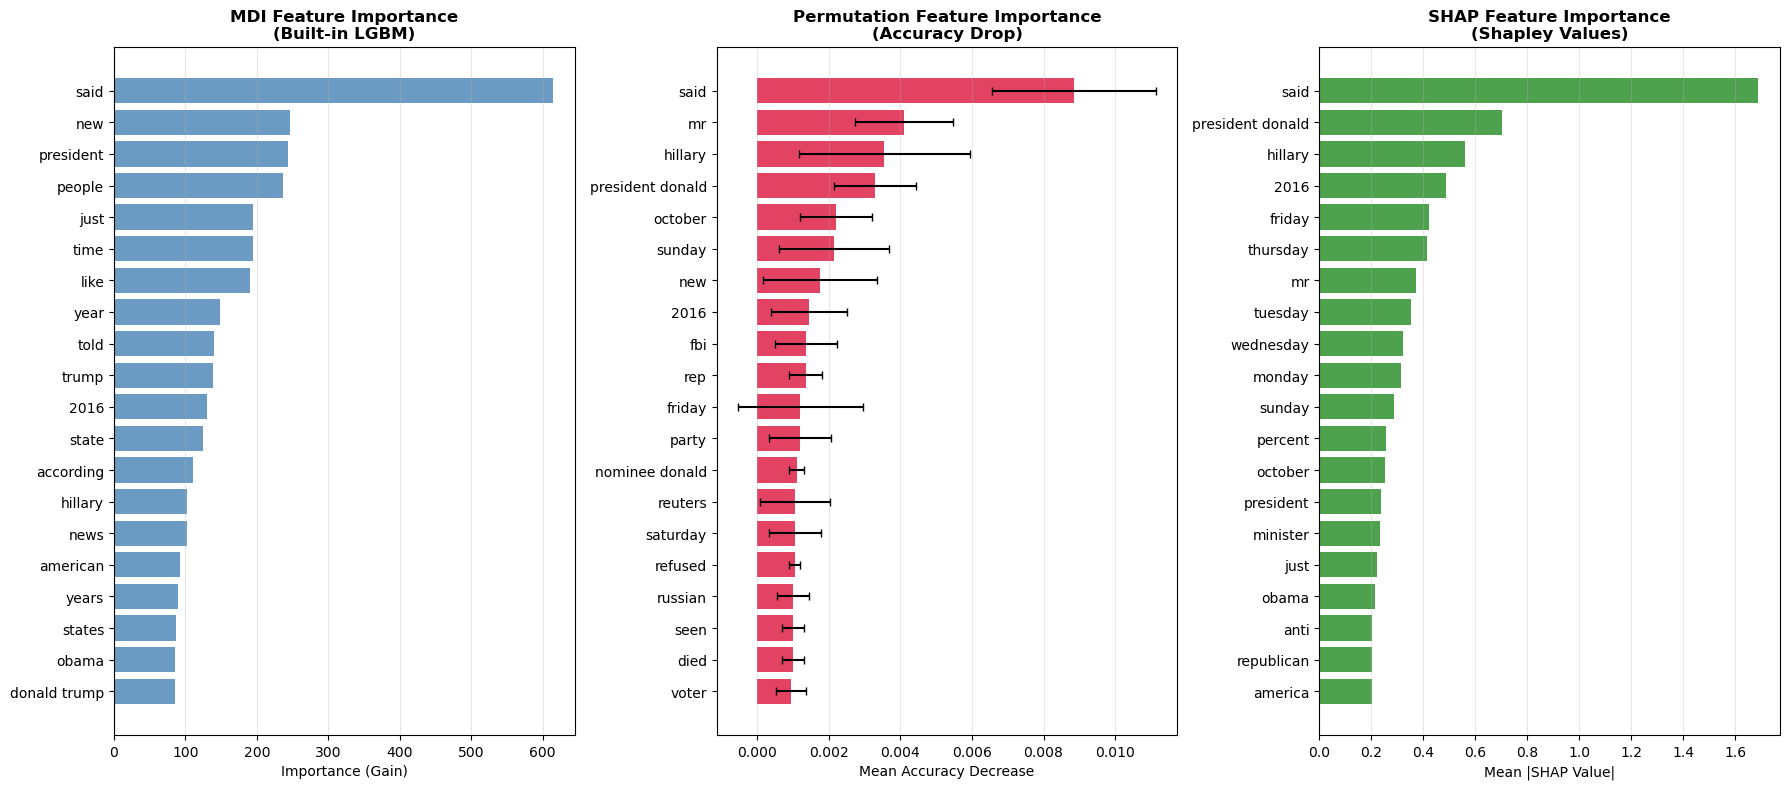


Figure saved to: results/figures/lgbm_optuna_feature_importance.png


In [21]:
# Visualize feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# MDI Feature Importance
ax1 = axes[0]
top_mdi = mdi_df.head(20)
y_pos = np.arange(len(top_mdi))
ax1.barh(y_pos, top_mdi['importance'].values, color='steelblue', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_mdi['feature'].values)
ax1.invert_yaxis()
ax1.set_xlabel('Importance (Gain)')
ax1.set_title('MDI Feature Importance\n(Built-in LGBM)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Permutation Feature Importance
ax2 = axes[1]
top_perm = perm_df.head(20)
y_pos = np.arange(len(top_perm))
ax2.barh(y_pos, top_perm['importance_mean'].values, color='crimson', alpha=0.8, 
         xerr=top_perm['importance_std'].values, capsize=3)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_perm['feature'].values)
ax2.invert_yaxis()
ax2.set_xlabel('Mean Accuracy Decrease')
ax2.set_title('Permutation Feature Importance\n(Accuracy Drop)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# SHAP Feature Importance
ax3 = axes[2]
if shap_available:
    top_shap = shap_df.head(20)
    y_pos = np.arange(len(top_shap))
    ax3.barh(y_pos, top_shap['shap_importance'].values, color='forestgreen', alpha=0.8)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(top_shap['feature'].values)
    ax3.invert_yaxis()
    ax3.set_xlabel('Mean |SHAP Value|')
    ax3.set_title('SHAP Feature Importance\n(Shapley Values)', fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'SHAP not available', ha='center', va='center', fontsize=14)
    ax3.set_title('SHAP Feature Importance', fontweight='bold')

plt.tight_layout()
plt.savefig(str(project_root / "results" / "figures" / "lgbm_optuna_feature_importance.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure saved to: results/figures/lgbm_optuna_feature_importance.png")


In [22]:
# Final Summary
print("=" * 60)
print("LGBM OPTUNA EXPERIMENT SUMMARY")
print("=" * 60)

print(f"\n** Optimization **")
print(f"  Trials: {N_TRIALS}")
print(f"  Best CV F1-score: {study.best_value:.4f}")

print(f"\n** Best Hyperparameters **")
for param, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.6f}")
    else:
        print(f"  {param}: {value}")

print(f"\n** Test Set Results **")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1-score (macro): {test_f1:.4f}")

print(f"\n** Classification Report **")
for label, name in [('Real (0)', 'Real (0)'), ('Fake (1)', 'Fake (1)')]:
    print(f"  {name}:")
    print(f"    Precision: {report[label]['precision']:.4f}")
    print(f"    Recall:    {report[label]['recall']:.4f}")
    print(f"    F1-score:  {report[label]['f1-score']:.4f}")

print(f"\n** Top 5 Features (by MDI) **")
for i, (_, row) in enumerate(mdi_df.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature']}: {row['importance']:.0f}")


LGBM OPTUNA EXPERIMENT SUMMARY

** Optimization **
  Trials: 100
  Best CV F1-score: 0.9331

** Best Hyperparameters **
  n_estimators: 499
  learning_rate: 0.287572
  num_leaves: 46
  max_depth: 12
  min_child_samples: 59
  subsample: 0.631136
  colsample_bytree: 0.505511
  reg_alpha: 0.003473
  reg_lambda: 0.003938

** Test Set Results **
  Accuracy: 0.9412
  F1-score (macro): 0.9336

** Classification Report **
  Real (0):
    Precision: 0.9508
    Recall:    0.9613
    F1-score:  0.9560
  Fake (1):
    Precision: 0.9213
    Recall:    0.9012
    F1-score:  0.9112

** Top 5 Features (by MDI) **
  1. said: 614
  2. new: 246
  3. president: 244
  4. people: 236
  5. just: 195


In [23]:
# Save the optimized model
model_path = project_root / "results" / "models" / "lgbm_optuna.pkl"
joblib.dump(final_model, str(model_path))
print(f"✓ Optimized model saved to: {model_path}")

# Save best hyperparameters
params_path = project_root / "results" / "models" / "lgbm_optuna_params.pkl"
joblib.dump(study.best_params, str(params_path))
print(f"✓ Best hyperparameters saved to: {params_path}")


✓ Optimized model saved to: /Users/alanye/Fake-News-Group-3/results/models/lgbm_optuna.pkl
✓ Best hyperparameters saved to: /Users/alanye/Fake-News-Group-3/results/models/lgbm_optuna_params.pkl


In [24]:
print("\n" + "=" * 60)
print("3. SHAP (SHapley Additive exPlanations)")
print("   (Game-theoretic feature attributions)")
print("=" * 60)

try:
    import shap
    
    # Use a sample of test data for SHAP (to keep computation manageable)
    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test[:sample_size].toarray()  # Convert sparse to dense for SHAP
    
    print(f"\nComputing SHAP values on {sample_size} samples...")
    
    # Create SHAP explainer for tree-based model
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_sample)
    
    # For binary classification, take absolute mean of SHAP values
    if isinstance(shap_values, list):
        # Binary classification returns [class0_shap, class1_shap]
        shap_importance = np.abs(shap_values[1]).mean(axis=0)
    else:
        shap_importance = np.abs(shap_values).mean(axis=0)
    
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance
    }).sort_values('shap_importance', ascending=False)
    
    print(f"\nTop 20 features by SHAP importance:")
    print(shap_df.head(20).to_string(index=False))
    
    shap_available = True
except ImportError:
    print("\nSHAP library not installed. Install with: pip install shap")
    shap_available = False
except Exception as e:
    print(f"\nError computing SHAP values: {e}")
    shap_available = False



3. SHAP (SHapley Additive exPlanations)
   (Game-theoretic feature attributions)

Computing SHAP values on 1000 samples...

Top 20 features by SHAP importance:
         feature  shap_importance
            said         1.686921
president donald         0.703462
         hillary         0.558560
            2016         0.486162
          friday         0.423087
        thursday         0.412742
              mr         0.372263
         tuesday         0.352255
       wednesday         0.323140
          monday         0.314418
          sunday         0.287347
         percent         0.256678
         october         0.254189
       president         0.237102
        minister         0.234858
            just         0.219949
           obama         0.213271
            anti         0.203962
      republican         0.203713
         america         0.202559


In [25]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'
